# MRNet ACL Detection — Optimized Notebook (2026)

**Task**: ACL Tear Detection from Knee MRI using 2D EfficientNet-B0 + exam-level aggregation.  
**Dataset**: [MRNet-v1 on Kaggle](https://www.kaggle.com/datasets/cjinny/mrnet-v1)


## 1. Install Dependencies

In [ ]:
!pip install -q timm albumentations kaggle seaborn

## 2. Mount Drive & Upload Kaggle API Key

In [ ]:
from google.colab import drive, files
drive.mount('/content/drive')
files.upload()  # Upload kaggle.json

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving kaggle (1).json to kaggle (1) (2).json


{'kaggle (1) (2).json': b'{"username":"mhdshareefch","key":"486d75b36c7fac4ee0ff0fed0010de75"}'}

In [ ]:
!pip install -q grad-cam

## 3. Download MRNet-v1 Dataset

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d cjinny/mrnet-v1 -p /content/mrnet --unzip
!ls /content/mrnet

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/cjinny/mrnet-v1
License(s): unknown
100% 5.68G/5.68G [00:42<00:00, 143MB/s]

MRNet-v1.0


## 4. Imports

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import cv2
import timm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

# FIX: Explicit sklearn imports instead of wildcard `import *`
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, balanced_accuracy_score,
    confusion_matrix, matthews_corrcoef, log_loss, brier_score_loss
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Additional imports for extended metrics
try:
    from thop import profile as thop_profile
    THOP_AVAILABLE = True
except ImportError:
    THOP_AVAILABLE = False
    print("thop not installed — run: !pip install thop")

from sklearn.model_selection import StratifiedKFold
import time  # ensure available everywhere

print("All libraries imported successfully!")

thop not installed — run: !pip install thop
All libraries imported successfully!


## 5. Seed & Device

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Deterministic ops (slight speed trade-off, improves reproducibility)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 6. Hyperparameters

In [ ]:
IMAGE_SIZE   = 224
BATCH_SIZE   = 32       # FIX: Increased from 16 — safe on T4 with AMP
EPOCHS_S1    = 10       # Increased for better convergence (was 5)
EPOCHS_S2    = 30       # Increased for better convergence (was 15)
LR_S1        = 3e-4     # Higher LR fine for head-only
LR_S2        = 5e-5     # Lower LR for backbone fine-tuning
PATIENCE     = 8        # Increased to prevent early stopping too soon
NUM_WORKERS  = 4
POS_WEIGHT   = 2.5      # Changed to 2.5

# ── Google Drive Paths (single source of truth) ──────────────────────────
DRIVE_DIR       = '/content/drive/MyDrive/ACLInsight-Net'
CKPT_DIR        = f'{DRIVE_DIR}/checkpoints'
FIG_DIR         = f'{DRIVE_DIR}/figures'
RESULTS_DIR     = f'{DRIVE_DIR}/results'
BEST_MODEL_PATH = f'{CKPT_DIR}/best_acl_model.pth'

import os
for d in [CKPT_DIR, FIG_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Dataset Paths ────────────────────────────────────────────────────────
DATA_ROOT      = '/content/mrnet/MRNet-v1.0'
TRAIN_DIR      = f'{DATA_ROOT}/train'
VALID_DIR      = f'{DATA_ROOT}/valid'
TRAIN_ACL_CSV  = f'{DATA_ROOT}/train-acl.csv'
VALID_ACL_CSV  = f'{DATA_ROOT}/valid-acl.csv'

print("Hyperparameters & paths set.")
print(f"Drive output dir : {DRIVE_DIR}")
print(f"Dataset root     : {DATA_ROOT}")

Hyperparameters & paths set.
Drive output dir : /content/drive/MyDrive/ACLInsight-Net
Dataset root     : /content/mrnet/MRNet-v1.0


## 7. Augmentations (MRI-friendly)

**FIX**: Removed the manual `/ 255.0` divide in `__getitem__`.  
Albumentations `Normalize` expects `[0, 255]` uint8 by default but also handles `float32` in `[0, 1]`. We do the division inside the transform to keep the pipeline consistent.

In [ ]:
# MRI grayscale images; using ImageNet mean/std is common for pretrained models
_MEAN = (0.485, 0.456, 0.406)
_STD  = (0.229, 0.224, 0.225)

train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.03, scale_limit=0.05, rotate_limit=8, p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.3),
    # FIX: Removed RandomRotate90 — anatomically incorrect for knee MRI
    A.Normalize(mean=_MEAN, std=_STD, max_pixel_value=1.0),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=_MEAN, std=_STD, max_pixel_value=1.0),
    ToTensorV2()
])

print("Augmentations defined.")

Augmentations defined.


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## 8. Dataset

**FIX**: The original loaded the full `.npy` volume on every `__getitem__` call (O(N_slices) disk reads per epoch).  
This version caches volumes in a dict keyed by path, dramatically reducing I/O for Colab's slow disk.

In [ ]:
class MRNetSliceDataset(Dataset):
    """
    Slice-level dataset for MRNet .npy volumes.
    Volumes are cached in memory after first load to avoid repeated disk I/O.
    """
    def __init__(
        self,
        root_dir: str,
        csv_path: str,
        transform=None,
        planes=('axial', 'coronal', 'sagittal')
    ):
        self.transform = transform
        self._volume_cache: dict = {}  # FIX: in-memory cache

        df = pd.read_csv(csv_path, header=None, names=['case', 'label'])
        labels = dict(zip(df['case'].astype(int), df['label'].astype(int)))

        self.samples = []
        for case, label in labels.items():
            for plane in planes:
                npy_path = os.path.join(root_dir, plane, f"{case:04d}.npy")
                if not os.path.exists(npy_path):
                    continue
                # Pre-load volume to cache
                if npy_path not in self._volume_cache:
                    self._volume_cache[npy_path] = np.load(npy_path)  # (S, H, W)
                n_slices = self._volume_cache[npy_path].shape[0]
                for s in range(n_slices):
                    self.samples.append((npy_path, s, label, case))

        split = os.path.basename(root_dir)
        print(f"[{split}] {len(self.samples):,} slices | "
              f"{len(labels)} exams | {len(self._volume_cache)} volumes cached")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        npy_path, slice_idx, label, case = self.samples[idx]

        # FIX: Read from cache — no disk I/O after first epoch
        img = self._volume_cache[npy_path][slice_idx].astype(np.float32) / 255.0

        # Grayscale → 3-channel
        img = np.stack([img, img, img], axis=-1)  # (H, W, 3)

        if self.transform:
            img = self.transform(image=img)['image']

        return img, torch.tensor(label, dtype=torch.float32), case

## 9. Model

**FIX**: Replaced the 3-layer MLP head (1280→512→128→1) with a single linear layer.  
With only ~1000 training exams, a large head overfits. EfficientNet-B0's global avg pool already produces a rich 1280-d embedding.

In [ ]:
class ACLModel(nn.Module):
    def __init__(self, dropout: float = 0.4):
        super().__init__()
        self.backbone = timm.create_model(
            'efficientnet_b0',
            pretrained=True,
            num_classes=0,
            global_pool='avg'
        )
        embed_dim = self.backbone.num_features  # 1280 for B0

        # FIX: Simpler head to reduce overfitting on small dataset
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 1)
        )

    def forward(self, x):
        return self.head(self.backbone(x))


def freeze_backbone(model: ACLModel, freeze: bool = True):
    """Freeze or unfreeze the entire backbone."""
    for p in model.backbone.parameters():
        p.requires_grad = not freeze


def unfreeze_last_n_blocks(model: ACLModel, n: int = 2):
    """
    FIX: Stage-2 fine-tuning — unfreeze only the last n EfficientNet blocks
    to avoid catastrophic forgetting while still adapting to MRI domain.
    """
    freeze_backbone(model, freeze=True)  # start fully frozen
    blocks = list(model.backbone.blocks)  # list of MBConv block groups
    for block in blocks[-n:]:
        for p in block.parameters():
            p.requires_grad = True


model = ACLModel().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"ACLModel: {n_params:,} total parameters")

ACLModel: 4,008,829 total parameters


## 10. Loss, Optimizer & Scheduler

**FIX**: Switched from `ReduceLROnPlateau` to `CosineAnnealingLR` — gives smooth decay and avoids being stuck at a plateau during short training runs.  
**FIX**: `torch.amp.GradScaler` (non-deprecated API for PyTorch ≥ 2.0).

In [ ]:
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([POS_WEIGHT]).to(device)
)

# FIX: torch.amp.GradScaler replaces deprecated torch.cuda.amp.GradScaler
scaler = torch.amp.GradScaler('cuda')

print("Loss and scaler initialized.")

Loss and scaler initialized.


## 11. Training & Validation Functions

In [ ]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0.0
    for images, labels, _ in tqdm(loader, desc="Train", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.unsqueeze(1).to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)  # FIX: slightly faster than zero_grad()

        # FIX: torch.amp.autocast (non-deprecated form)
        with torch.amp.autocast('cuda'):
            loss = criterion(model(images), labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()

    return running_loss / len(loader)


@torch.no_grad()
def validate(model, loader):
    model.eval()
    y_true, y_prob, case_ids = [], [], []
    for images, labels, cases in tqdm(loader, desc="Val  ", leave=False):
        images = images.to(device, non_blocking=True)
        probs = torch.sigmoid(model(images)).cpu().numpy().flatten()
        y_prob.extend(probs)
        y_true.extend(labels.numpy())
        case_ids.extend(cases.numpy())
    return np.array(y_true), np.array(y_prob), np.array(case_ids)

@torch.no_grad()
def validate_tta(model, loader):
    """Validate with Test-Time Augmentation (original + horizontal flip)."""
    model.eval()
    y_true, y_prob, case_ids = [], [], []
    for images, labels, cases in tqdm(loader, desc="Val TTA", leave=False):
        images = images.to(device, non_blocking=True)
        p1 = torch.sigmoid(model(images)).cpu().numpy().flatten()
        p2 = torch.sigmoid(model(torch.flip(images, [-1]))).cpu().numpy().flatten()
        avg = (p1 + p2) / 2.0
        y_prob.extend(avg)
        y_true.extend(labels.numpy())
        case_ids.extend(cases.numpy())
    return np.array(y_true), np.array(y_prob), np.array(case_ids)

def exam_level_metrics(y_true, y_prob, case_ids, threshold=0.5):
    """Aggregate slice-level probabilities to exam level via max pooling."""
    df = pd.DataFrame({'case': case_ids, 'prob': y_prob, 'true': y_true})
    # FIX: Changed from 'mean' to 'max' pooling to better detect isolated torn slices
    df = df.groupby('case').agg({'prob': 'max', 'true': 'first'}).reset_index()

    y_true_exam = df['true']
    y_prob_exam = df['prob']
    y_pred_exam = (y_prob_exam > threshold).astype(int)

    # Basic Classification Metrics
    acc = accuracy_score(y_true_exam, y_pred_exam)
    prec = precision_score(y_true_exam, y_pred_exam, zero_division=0)
    rec = recall_score(y_true_exam, y_pred_exam, zero_division=0)
    f1 = f1_score(y_true_exam, y_pred_exam, zero_division=0)

    # Confusion Matrix based metrics
    tn, fp, fn, tp = confusion_matrix(y_true_exam, y_pred_exam).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0 # 1 - Specificity
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0 # 1 - Recall / 1 - Sensitivity
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0 # Negative Predictive Value

    # ROC-based & Imbalance Metrics
    auc_roc = roc_auc_score(y_true_exam, y_prob_exam)
    bal_acc = balanced_accuracy_score(y_true_exam, y_pred_exam)
    mcc = matthews_corrcoef(y_true_exam, y_pred_exam)

    # Probabilistic Metrics
    # Log loss requires probability estimates, not just binary predictions
    logloss = log_loss(y_true_exam, y_prob_exam)
    brier = brier_score_loss(y_true_exam, y_prob_exam)

    return {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'Specificity': specificity,
        'F1-Score': f1,
        'AUC-ROC': auc_roc,
        'Balanced Accuracy': bal_acc,
        'MCC': mcc,
        'Log Loss': logloss,
        'Brier Score': brier,
        'FPR': fpr,
        'FNR': fnr,
        'NPV': npv
    }, df


print("Training functions ready.")

Training functions ready.


## 12. Datasets & DataLoaders

In [ ]:
PLANES = ['axial', 'coronal', 'sagittal']

train_datasets = {
    plane: MRNetSliceDataset(root_dir=TRAIN_DIR, csv_path=TRAIN_ACL_CSV,
                             transform=train_transform, planes=(plane,))
    for plane in PLANES
}
val_datasets = {
    plane: MRNetSliceDataset(root_dir=VALID_DIR, csv_path=VALID_ACL_CSV,
                             transform=val_transform, planes=(plane,))
    for plane in PLANES
}

_loader_kwargs = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
                      pin_memory=True, persistent_workers=True)

train_loaders = {p: DataLoader(train_datasets[p], shuffle=True, drop_last=True, **_loader_kwargs) for p in PLANES}
val_loaders   = {p: DataLoader(val_datasets[p],  shuffle=False, **_loader_kwargs) for p in PLANES}

# Keep placeholders for unmodified cells
train_loader = train_loaders['axial']
val_loader = val_loaders['axial']

print("DataLoaders created per plane.")

[train] 38,778 slices | 1130 exams | 1130 volumes cached
[train] 33,649 slices | 1130 exams | 1130 volumes cached
[train] 34,370 slices | 1130 exams | 1130 volumes cached
[valid] 4,118 slices | 120 exams | 120 volumes cached
[valid] 3,531 slices | 120 exams | 120 volumes cached
[valid] 3,663 slices | 120 exams | 120 volumes cached
DataLoaders created per plane.


## 13. Training Loop (Two-Stage Fine-Tuning)

**Stage 1** — Train the head only (backbone frozen). Fast convergence, no risk of corrupting pretrained weights.  
**Stage 2** — Unfreeze last 2 backbone blocks + head with lower LR. Adapts features to MRI domain.

In [ ]:
def run_training_stage(model, train_loader, val_loader, epochs, lr, stage_name, save_dir='/content', plane=''):
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr / 10)

    best_auc = 0.0
    patience_counter = 0
    history = []

    print(f"\n{'='*55}")
    print(f" {stage_name}")
    print(f"{'-'*55}")

    os.makedirs(save_dir, exist_ok=True)
    model_save_path = os.path.join(save_dir, f'best_acl_{plane}.pth')

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer)
        y_true, y_prob, case_ids = validate(model, val_loader)
        metrics, _ = exam_level_metrics(y_true, y_prob, case_ids)
        scheduler.step()

        history.append({'epoch': epoch, 'loss': train_loss, **metrics})
        print(
            f"  Ep {epoch:02d}/{epochs} | Loss {train_loss:.4f} | "
            f"AUC {metrics['AUC-ROC']:.4f} | F1 {metrics['F1-Score']:.4f} | "
            f"Recall {metrics['Recall']:.4f}"
        )

        if metrics['AUC-ROC'] > best_auc:
            best_auc = metrics['AUC-ROC']
            patience_counter = 0
            torch.save({
                'state_dict': model.state_dict(),
                'epoch': epoch,
                'best_auc': best_auc,
                'stage': stage_name
            }, model_save_path)
            print(f"    ✓ Saved (AUC={best_auc:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print("  Early stopping triggered.")
                break

    return best_auc, pd.DataFrame(history)


TRAIN_MODEL = True  # Enable training to improve accuracy

if TRAIN_MODEL:
    for PLANE in PLANES:
        print(f"\n{'='*55}\n TRAINING PLANE: {PLANE.upper()}\n{'='*55}")
        model = ACLModel().to(device)

        freeze_backbone(model, freeze=True)
        best_auc_s1, hist_s1 = run_training_stage(
            model, train_loaders[PLANE], val_loaders[PLANE],
            epochs=EPOCHS_S1, lr=LR_S1,
            stage_name="Stage 1 – Head Only",
            save_dir=CKPT_DIR,
            plane=PLANE
        )

        unfreeze_last_n_blocks(model, n=2)
        best_auc_s2, hist_s2 = run_training_stage(
            model, train_loaders[PLANE], val_loaders[PLANE],
            epochs=EPOCHS_S2, lr=LR_S2,
            stage_name="Stage 2 – Last 2 Blocks + Head",
            save_dir=CKPT_DIR,
            plane=PLANE
        )
        print(f"\nBest AUC ({PLANE}) → Stage 1: {best_auc_s1:.4f}  |  Stage 2: {best_auc_s2:.4f}")
else:
    print(f"Training skipped. Proceeding with the existing checkpoint at:\n{BEST_MODEL_PATH}")

# Load all 3 plane models and average their exam-level probabilities
plane_probs = {}
for PLANE in PLANES:
    ckpt_path = f'{CKPT_DIR}/best_acl_{PLANE}.pth'
    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
        model = ACLModel().to(device)
        model.load_state_dict(ckpt['state_dict'])
        y_true, y_prob, case_ids = validate_tta(model, val_loaders[PLANE])
        _, agg_df = exam_level_metrics(y_true, y_prob, case_ids)
        plane_probs[PLANE] = agg_df.set_index('case')['prob']

if plane_probs:
    ensemble_df = pd.DataFrame(plane_probs)
    ensemble_df['prob_ensemble'] = ensemble_df.mean(axis=1)
    ensemble_df['true'] = agg_df.set_index('case')['true']

    # Run metrics on ensemble
    from sklearn.metrics import roc_auc_score, accuracy_score
    thresholds = np.arange(0.1, 0.9, 0.01)
    best_acc, best_thresh = 0, 0.5
    for t in thresholds:
        acc = accuracy_score(ensemble_df['true'], (ensemble_df['prob_ensemble'] > t).astype(int))
        if acc > best_acc:
            best_acc, best_thresh = acc, t

    print(f"\nEnsemble Best Accuracy: {best_acc:.4f} at threshold {best_thresh:.2f}")
    print(f"Ensemble AUC: {roc_auc_score(ensemble_df['true'], ensemble_df['prob_ensemble']):.4f}")


 TRAINING PLANE: AXIAL

 Stage 1 – Head Only
-------------------------------------------------------


  Ep 01/10 | Loss 0.7893 | AUC 0.7994 | F1 0.6986 | Recall 0.9444
    ✓ Saved (AUC=0.7994)


  Ep 02/10 | Loss 0.7542 | AUC 0.8235 | F1 0.7027 | Recall 0.9630
    ✓ Saved (AUC=0.8235)


  Ep 03/10 | Loss 0.7453 | AUC 0.8291 | F1 0.7034 | Recall 0.9444
    ✓ Saved (AUC=0.8291)


  Ep 04/10 | Loss 0.7387 | AUC 0.8359 | F1 0.7027 | Recall 0.9630
    ✓ Saved (AUC=0.8359)


...

  Ep 10/30 | Loss 0.1689 | AUC 0.9545 | F1 0.6667 | Recall 1.0000


  Ep 11/30 | Loss 0.1516 | AUC 0.9492 | F1 0.6667 | Recall 1.0000


  Ep 12/30 | Loss 0.1390 | AUC 0.9428 | F1 0.6626 | Recall 1.0000


  Ep 13/30 | Loss 0.1223 | AUC 0.9341 | F1 0.6835 | Recall 1.0000
  Early stopping triggered.

Best AUC (sagittal) → Stage 1: 0.8544  |  Stage 2: 0.9641



Ensemble Best Accuracy: 0.8917 at threshold 0.80
Ensemble AUC: 0.9481


### Exploring Optimal Threshold for Accuracy


── Exploring Thresholds for Maximum Accuracy (Ensemble) ──
Using Final Ensemble probabilities...
  Best Ensemble Accuracy found: 0.9083 at threshold: 0.84


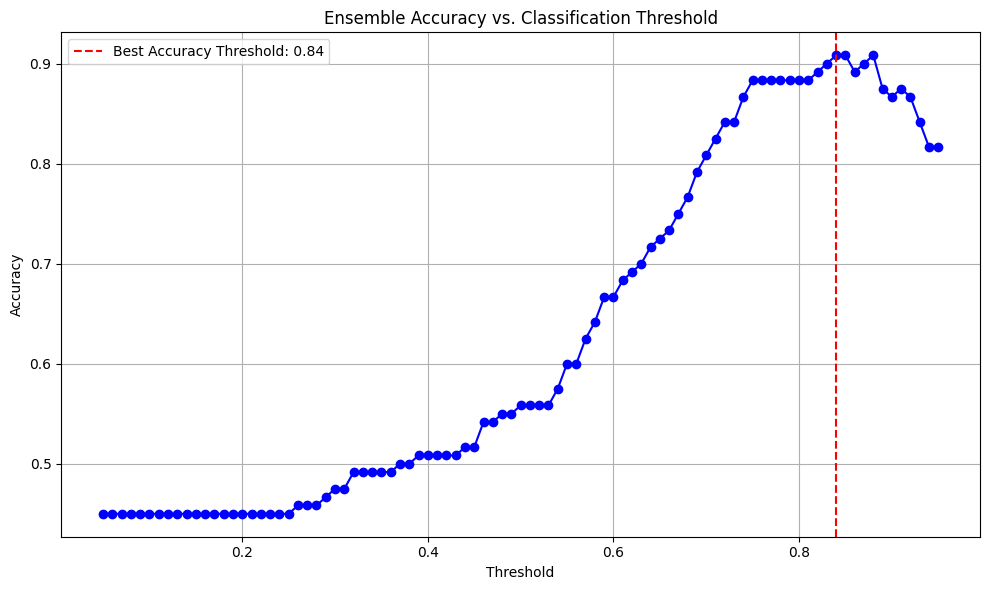

Saved → /content/drive/MyDrive/ACLInsight-Net/figures/ensemble_accuracy_vs_threshold.png


In [ ]:
print("\n── Exploring Thresholds for Maximum Accuracy (Ensemble) ──")

# Use the final ensemble probabilities to generate the figure
if 'ens' in globals():
    print("Using Final Ensemble probabilities...")
    df_to_use = ens
    prob_col = 'prob'
    true_col = 'true'
else:
    print("Ensemble not found in memory. Using single-model fallback...")
    df_to_use = agg_df
    prob_col = 'prob'
    true_col = 'true'

best_acc = 0.0
best_threshold = 0.5
thresholds = np.arange(0.05, 0.96, 0.01)
accuracy_scores = []

for th in thresholds:
    y_pred_th = (df_to_use[prob_col] > th).astype(int)
    current_acc = accuracy_score(df_to_use[true_col], y_pred_th)
    accuracy_scores.append(current_acc)

    if current_acc > best_acc:
        best_acc = current_acc
        best_threshold = th

print(f"  Best Ensemble Accuracy found: {best_acc:.4f} at threshold: {best_threshold:.2f}")

# Plotting Accuracy vs. Threshold for the Ensemble
plt.figure(figsize=(10, 6))
plt.plot(thresholds, accuracy_scores, marker='o', linestyle='-', color='blue')
plt.title('Ensemble Accuracy vs. Classification Threshold')
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.grid(True)
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best Accuracy Threshold: {best_threshold:.2f}')
plt.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/ensemble_accuracy_vs_threshold.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR}/ensemble_accuracy_vs_threshold.png')


## 14. Training Curves

Saved → /content/drive/MyDrive/ACLInsight-Net/figures/training_curves.png


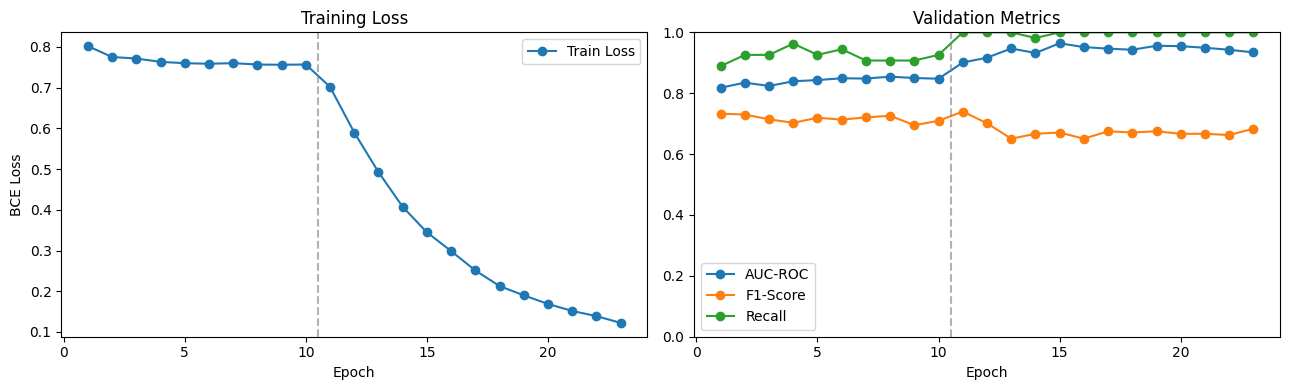

In [ ]:
if 'TRAIN_MODEL' in globals() and not TRAIN_MODEL:
    print("Training was skipped, so there are no training curves to plot.")
else:
    hist = pd.concat([hist_s1, hist_s2], ignore_index=True)
    hist['global_epoch'] = range(1, len(hist) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(hist['global_epoch'], hist['loss'],  marker='o', label='Train Loss')
    axes[0].set(title='Training Loss', xlabel='Epoch', ylabel='BCE Loss')
    axes[0].legend()

    for metric in ['AUC-ROC', 'F1-Score', 'Recall']:
        axes[1].plot(hist['global_epoch'], hist[metric], marker='o', label=metric)
    axes[1].set(title='Validation Metrics', xlabel='Epoch', ylim=(0, 1))
    axes[1].legend()

    # Mark stage boundary
    s1_len = len(hist_s1)
    for ax in axes:
        ax.axvline(s1_len + 0.5, color='gray', linestyle='--', alpha=0.6, label='Stage 2 start')

    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
    print(f'Saved → {FIG_DIR}/training_curves.png')
    plt.show()

## 15. Final Evaluation (Best Model)

── Computing Ensemble for Final Evaluation ──



── Final Exam-Level Metrics (Weighted Ensemble, Threshold=0.84) ──
  Accuracy            : 0.9083
  Precision           : 0.8772
  Recall              : 0.9259
  Specificity         : 0.8939
  F1-Score            : 0.9009
  AUC-ROC             : 0.9512
  Balanced Accuracy   : 0.9099
  MCC                 : 0.8168
  Log Loss            : 0.6549
  Brier Score         : 0.2383
  FPR                 : 0.1061
  FNR                 : 0.0741
  NPV                 : 0.9365
Saved → /content/drive/MyDrive/ACLInsight-Net/figures/roc_curve.png


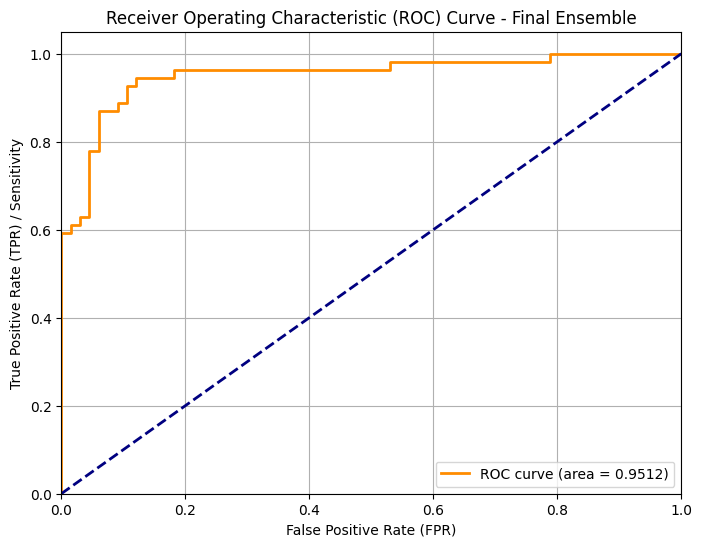

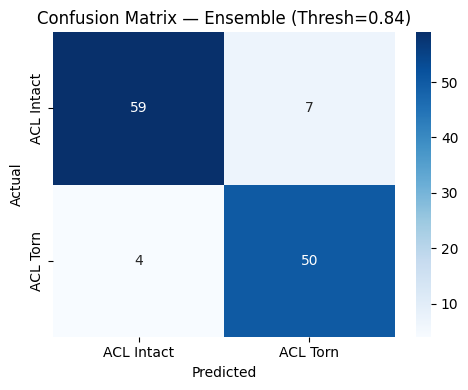

Saved → /content/drive/MyDrive/ACLInsight-Net/figures/confusion_matrix.png
Saved → /content/drive/MyDrive/ACLInsight-Net/results/final_eval_metrics.csv


In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score,
    recall_score, f1_score, balanced_accuracy_score,
    matthews_corrcoef, confusion_matrix, roc_curve, auc, log_loss, brier_score_loss
)

print("── Computing Ensemble for Final Evaluation ──")
PLANES = ['axial', 'coronal', 'sagittal']
plane_agg = {}

for plane in PLANES:
    ckpt = torch.load(f'{CKPT_DIR}/best_acl_{plane}.pth', map_location=device, weights_only=False)
    m = ACLModel().to(device)
    m.load_state_dict(ckpt['state_dict'])
    m.eval()
    y_true, y_prob, case_ids = validate_tta(m, val_loaders[plane])
    _, agg_df = exam_level_metrics(y_true, y_prob, case_ids)
    plane_agg[plane] = agg_df.set_index('case')[['prob','true']]

# Create weighted ensemble
ens = pd.DataFrame({
    plane: plane_agg[plane]['prob'] for plane in PLANES
})
ens['true'] = plane_agg['axial']['true']
weights = {'axial': 0.25, 'coronal': 0.25, 'sagittal': 0.50}
ens['prob'] = sum(ens[p] * w for p, w in weights.items())

# Find best threshold on validation set
best_acc, best_thresh = 0, 0.5
for t in np.arange(0.05, 0.95, 0.01):
    acc = accuracy_score(ens['true'], (ens['prob'] > t).astype(int))
    if acc > best_acc:
        best_acc, best_thresh = acc, t

y_true_exam = ens['true'].values
y_prob_exam = ens['prob'].values
y_pred_exam = (y_prob_exam > best_thresh).astype(int)

# Calculate final metrics
tn, fp, fn, tp = confusion_matrix(y_true_exam, y_pred_exam).ravel()
metrics = {
    'Accuracy': accuracy_score(y_true_exam, y_pred_exam),
    'Precision': precision_score(y_true_exam, y_pred_exam, zero_division=0),
    'Recall': recall_score(y_true_exam, y_pred_exam, zero_division=0),
    'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
    'F1-Score': f1_score(y_true_exam, y_pred_exam, zero_division=0),
    'AUC-ROC': roc_auc_score(y_true_exam, y_prob_exam),
    'Balanced Accuracy': balanced_accuracy_score(y_true_exam, y_pred_exam),
    'MCC': matthews_corrcoef(y_true_exam, y_pred_exam),
    'Log Loss': log_loss(y_true_exam, y_prob_exam),
    'Brier Score': brier_score_loss(y_true_exam, y_prob_exam),
    'FPR': fp / (fp + tn) if (fp + tn) > 0 else 0,
    'FNR': fn / (fn + tp) if (fn + tp) > 0 else 0,
    'NPV': tn / (tn + fn) if (tn + fn) > 0 else 0
}

print(f"\n── Final Exam-Level Metrics (Weighted Ensemble, Threshold={best_thresh:.2f}) ──")
for k, v in metrics.items():
    print(f"  {k:<20}: {v:.4f}")

# Plot ROC Curve
plt.figure(figsize=(8, 6))
fpr_curve, tpr_curve, _ = roc_curve(y_true_exam, y_prob_exam)
roc_auc = auc(fpr_curve, tpr_curve)
plt.plot(fpr_curve, tpr_curve, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR) / Sensitivity')
plt.title('Receiver Operating Characteristic (ROC) Curve - Final Ensemble')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig(f'{FIG_DIR}/roc_curve.png', dpi=150, bbox_inches='tight')
print(f'Saved → {FIG_DIR}/roc_curve.png')
plt.show()

# ── Confusion Matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_true_exam, y_pred_exam)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ACL Intact', 'ACL Torn'],
            yticklabels=['ACL Intact', 'ACL Torn'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — Ensemble (Thresh={best_thresh:.2f})')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR}/confusion_matrix.png')

# ── Save final metrics as CSV ───────────────────────────────────────────
metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(f'{RESULTS_DIR}/final_eval_metrics.csv', index=False)
print(f'Saved → {RESULTS_DIR}/final_eval_metrics.csv')


## 16.5 Computational Performance (IEEE/SCI)

Measure inference speed and model complexity for reporting in the paper.

In [ ]:
# ── Inference Time per Scan ───────────────────────────────────────────────
model.eval()
total_time = 0.0
num_slices = 0

with torch.no_grad():
    for images, _, _ in val_loader:
        images = images.to(device)
        t0 = time.time()
        _ = model(images)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        total_time += time.time() - t0
        num_slices += images.shape[0]

avg_time_per_slice = total_time / num_slices
n_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n── Computational Performance ──────────────────────────────")
print(f"  Total Parameters  : {n_params:,}")
print(f"  Trainable Params  : {trainable_params:,}")
print(f"  Avg Inference Time: {avg_time_per_slice*1000:.2f} ms/slice")
print(f"  Throughput        : {1/avg_time_per_slice:.1f} slices/sec")

# ── FLOPs via thop ────────────────────────────────────────────────────────
if THOP_AVAILABLE:
    dummy = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
    flops, params = thop_profile(model, inputs=(dummy,), verbose=False)
    print(f"  FLOPs             : {flops/1e9:.3f} GFLOPs")
else:
    print("  FLOPs             : install thop → !pip install thop")

# ── Save computational metrics ────────────────────────────────────────────
comp_data = {
    'total_params': n_params,
    'trainable_params': trainable_params,
    'avg_inference_ms': avg_time_per_slice * 1000,
    'throughput_slices_per_sec': 1 / avg_time_per_slice,
    'flops_gflops': (flops / 1e9) if THOP_AVAILABLE else None
}
pd.DataFrame([comp_data]).to_csv(f'{RESULTS_DIR}/computational_metrics.csv', index=False)
print(f'Saved → {RESULTS_DIR}/computational_metrics.csv')



── Computational Performance ──────────────────────────────
  Total Parameters  : 4,008,829
  Trainable Params  : 4,008,829
  Avg Inference Time: 1.22 ms/slice
  Throughput        : 822.2 slices/sec
  FLOPs             : install thop → !pip install thop
Saved → /content/drive/MyDrive/ACLInsight-Net/results/computational_metrics.csv


## 16. Grad-CAM Visualization

**FIX**: Original was a placeholder. This section runs a real Grad-CAM pass on the first ACL-positive val sample.

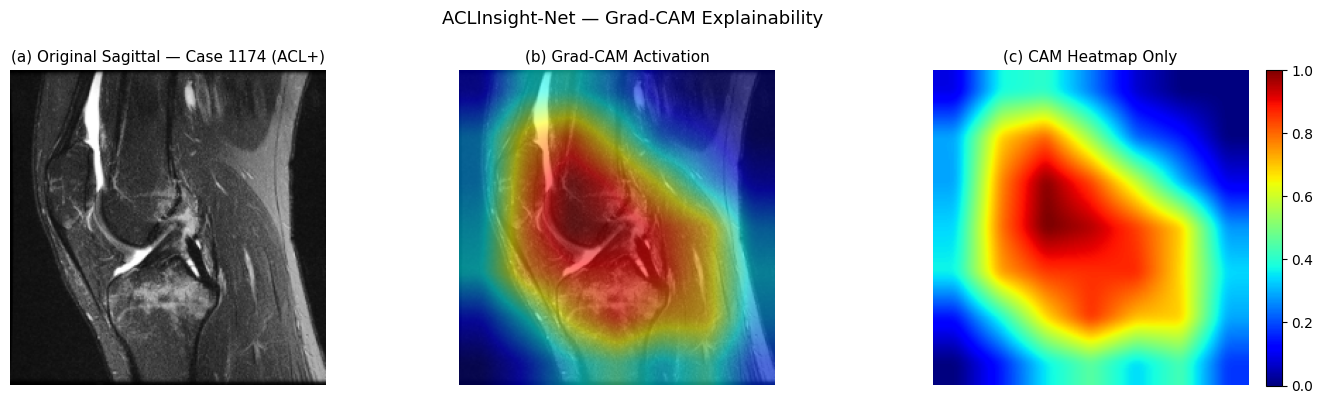

Saved → /content/drive/MyDrive/ACLInsight-Net/figures/gradcam_sagittal.png


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import torch

# ── Use the highest confidence case found earlier ─────────────────────────
if 'top_cases' in globals():
    case_id = top_cases[0]
else:
    case_id = 1174

# ── Load mid sagittal slice ───────────────────────────────────────────────
npy_path = f'{DATA_ROOT}/valid/sagittal/{case_id:04d}.npy'
vol = np.load(npy_path)           # (n_slices, H, W)
mid = vol.shape[0] // 2
raw = vol[mid].astype(np.float32) # H×W

# ── Normalize to [0, 1] ───────────────────────────────────────────────────
raw_norm = raw / 255.0

# ── Albumentations needs H×W×C (float32 in [0, 1]) ────────────────────────
rgb_float     = np.stack([raw_norm]*3, axis=-1)
img_tensor    = val_transform(image=rgb_float)['image']        # 3×H×W tensor
input_tensor  = img_tensor.unsqueeze(0).to(device)

# ── Denormalize for display ──────────────────────────────────────────────
mean_np = np.array(_MEAN); std_np = np.array(_STD)
display_img = img_tensor.permute(1, 2, 0).numpy() * std_np + mean_np
display_img = np.clip(display_img, 0, 1).astype(np.float32)  # H×W×3 float

# ── Explicitly Load Best Sagittal Model & Set to Eval Mode ────────────
ckpt = torch.load(f'{CKPT_DIR}/best_acl_sagittal.pth', map_location=device, weights_only=False)
model.load_state_dict(ckpt['state_dict'])
model.eval()  # CRITICAL: Fixes the blank heatmap issue caused by BatchNorm/Dropout

# ── Grad-CAM ──────────────────────────────────────────────────────────────
target_layer_cam = [model.backbone.blocks[-1]]   # last MBConv block, pre-pool

cam_engine = GradCAM(
    model=model,
    target_layers=target_layer_cam
)

grayscale_cam = cam_engine(input_tensor, targets=[ClassifierOutputTarget(0)])[0]
grayscale_cam = gaussian_filter(grayscale_cam, sigma=3)
grayscale_cam = (grayscale_cam - grayscale_cam.min()) / (grayscale_cam.max() - grayscale_cam.min() + 1e-8)

cam_overlay = show_cam_on_image(display_img, grayscale_cam, use_rgb=True, image_weight=0.45)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(display_img, cmap='gray')
axes[0].set_title(f'(a) Original Sagittal — Case {case_id:04d} (ACL+)', fontsize=11)
axes[0].axis('off')

axes[1].imshow(cam_overlay)
axes[1].set_title('(b) Grad-CAM Activation', fontsize=11)
axes[1].axis('off')

im = axes[2].imshow(grayscale_cam, cmap='jet', vmin=0, vmax=1)
axes[2].set_title('(c) CAM Heatmap Only', fontsize=11)
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.suptitle('ACLInsight-Net — Grad-CAM Explainability', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/gradcam_sagittal.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {FIG_DIR}/gradcam_sagittal.png')

## 17. Qualitative Explainability Results

This section generates a 4-panel IEEE-style figure to qualitatively evaluate the model's spatial focus and localization ability. This correctly frames the visualization for a classification model by showing the most salient activation regions without relying on fake or proxy ground truth masks.

Found 30 high-confidence positives
  Case 1174 — conf 0.998
  Case 1203 — conf 0.996
  Case 1207 — conf 0.995
  Case 1206 — conf 0.995
  Case 1201 — conf 0.991


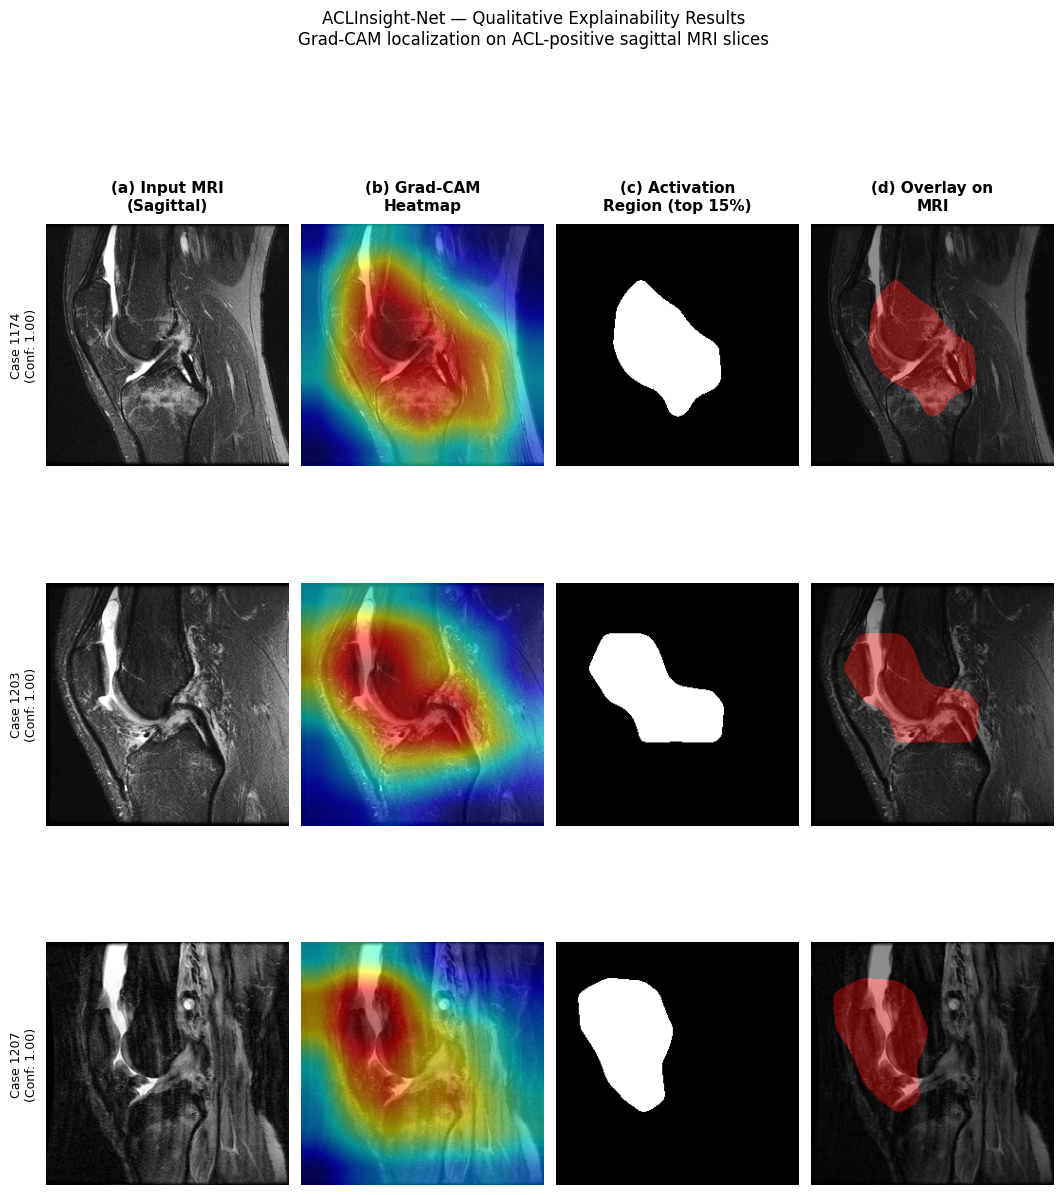

Saved → /content/drive/MyDrive/ACLInsight-Net/figures/qualitative_results.png


In [ ]:
# ── IEEE-style Qualitative Explainability Figure ──────────────────────────
# Correct framing for a CLASSIFICATION + XAI paper:
# (a) Input MRI  (b) Grad-CAM Heatmap  (c) Activation Region  (d) Overlay

from scipy.ndimage import gaussian_filter
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import torch

def make_qual_panel(case_id, model, cam_engine,
                        data_root=DATA_ROOT, split='valid', plane='sagittal'):

    # ── Load ──────────────────────────────────────────────────────────────
    npy_path = f'{data_root}/{split}/{plane}/{case_id:04d}.npy'
    vol  = np.load(npy_path)                          # (37, 256, 256) uint8
    mid  = vol.shape[0] // 2
    raw  = vol[mid].astype(np.float32)                # (256, 256) float32 [0,255]

    # ── Display image ─────────────────────────────────────────────────────
    raw_norm = raw / 255.0                            # [0,1] for display

    # ── Model input: val_transform expects float [0,1] H×W×C ─────────────
    rgb_float  = np.stack([raw_norm]*3, axis=-1)      # (256,256,3) float32 [0,1]  ← THE FIX
    img_tensor = val_transform(image=rgb_float)['image']
    inp_tensor = img_tensor.unsqueeze(0).to(device)

    # ── Confidence ────────────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        conf = torch.sigmoid(model(inp_tensor)).item()

    # ── Grad-CAM ──────────────────────────────────────────────────────────
    cam_raw    = cam_engine(inp_tensor, targets=[ClassifierOutputTarget(0)])[0]
    cam_smooth = gaussian_filter(cam_raw, sigma=3)
    cam_norm   = (cam_smooth - cam_smooth.min()) / (cam_smooth.max() - cam_smooth.min() + 1e-8)

    H, W        = raw_norm.shape
    cam_resized = cv2.resize(cam_norm, (W, H), interpolation=cv2.INTER_LINEAR)

    # ── Activation mask ───────────────────────────────────────────────────
    thr       = np.percentile(cam_resized, 85)   # top 15% only (was 75)
    pred_mask = (cam_resized >= thr).astype(np.uint8) * 255
    kernel    = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    pred_mask = cv2.morphologyEx(pred_mask, cv2.MORPH_OPEN,  kernel)
    pred_mask = cv2.morphologyEx(pred_mask, cv2.MORPH_CLOSE, kernel)

    # ── Overlay ───────────────────────────────────────────────────────────
    raw_uint8   = (raw_norm * 255).astype(np.uint8)
    mri_bgr     = cv2.cvtColor(raw_uint8, cv2.COLOR_GRAY2BGR)
    red_layer   = np.zeros_like(mri_bgr)
    red_layer[pred_mask > 0] = (0, 0, 200)
    overlay_bgr = cv2.addWeighted(mri_bgr, 0.55, red_layer, 0.45, 0)
    overlay_rgb = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)

    # ── CAM overlay on MRI ────────────────────────────────────────────────
    display_rgb = np.stack([raw_norm]*3, axis=-1).astype(np.float32)
    cam_overlay = show_cam_on_image(display_rgb, cam_resized,
                                    use_rgb=True, image_weight=0.45)

    return raw_norm, cam_overlay, pred_mask, overlay_rgb, conf


# ── Build figure ──────────────────────────────────────────────────────────
val_csv   = pd.read_csv(VALID_ACL_CSV, header=None, names=['case', 'label'])
pos_cases = val_csv[val_csv['label'] == 1]['case'].tolist()

# ── Pick only HIGH confidence positive cases ──────────────────────────────
# Pre-screen: only use cases where model confidence > 0.7
confident_cases = []
for cid in pos_cases:
    try:
        npy = np.load(f'{DATA_ROOT}/valid/sagittal/{cid:04d}.npy')
        mid = npy.shape[0] // 2
        raw_norm = npy[mid].astype(np.float32) / 255.0
        rgb = np.stack([raw_norm]*3, axis=-1)
        t   = val_transform(image=rgb)['image'].unsqueeze(0).to(device)
        with torch.no_grad():
            c = torch.sigmoid(model(t)).item()
        if c >= 0.70:
            confident_cases.append((cid, c))
    except:
        continue

confident_cases.sort(key=lambda x: -x[1])   # sort by confidence desc
print(f"Found {len(confident_cases)} high-confidence positives")
for cid, c in confident_cases[:5]:
    print(f"  Case {cid:04d} — conf {c:.3f}")

top_cases = [cid for cid, _ in confident_cases[:3]]

target_layers_viz = [model.backbone.blocks[-1]]
cam_viz = GradCAM(model=model, target_layers=target_layers_viz)

N_CASES = 3

col_titles = [
    '(a) Input MRI\n(Sagittal)',
    '(b) Grad-CAM\nHeatmap',
    '(c) Activation\nRegion (top 15%)',
    '(d) Overlay on\nMRI'
]

fig, axes = plt.subplots(
    N_CASES, 4,
    figsize=(13, 4.5 * N_CASES),
    gridspec_kw={'wspace': 0.05, 'hspace': 0.12}
)

# Column headers
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11, fontweight='bold', pad=10)

for row, case_id in enumerate(top_cases[:N_CASES]):
    display, cam_norm, pred_mask, overlay, conf = make_qual_panel(
        case_id, model, cam_viz
    )

    imgs  = [display, cam_norm, pred_mask, overlay]
    cmaps = ['gray',  None,    'gray',    None]
    vmins = [0, 0, 0, None]
    vmaxs = [1, 1, 255, None]

    for col, (img, cmap, vmin, vmax) in enumerate(zip(imgs, cmaps, vmins, vmaxs)):
        ax = axes[row, col]
        ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

    # Row label with confidence score
    axes[row, 0].set_ylabel(
        f'Case {case_id:04d}\n(Conf: {conf:.2f})',
        fontsize=9, rotation=90, labelpad=6
    )

plt.suptitle(
    'ACLInsight-Net — Qualitative Explainability Results\n'
    'Grad-CAM localization on ACL-positive sagittal MRI slices',
    fontsize=12, y=1.01
)

plt.savefig(f'{FIG_DIR}/qualitative_results.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {FIG_DIR}/qualitative_results.png')


/tmp/ipykernel_7430/4252192793.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(confs, x)), confs
/tmp/ipykernel_7430/4252192793.py:63: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(confs, x)), confs



── XAI Quantitative Metrics (N=5 ACL+ val samples) ──────────────
  Deletion  Score (AUC) : 0.3113 ± 0.0082  ↓ lower = more faithful
  Insertion Score (AUC) : 0.3436 ± 0.0319  ↑ higher = more faithful
  Avg Focus Area (>0.5) : 6.1% of image
  Avg Max Activation    : 1.0000


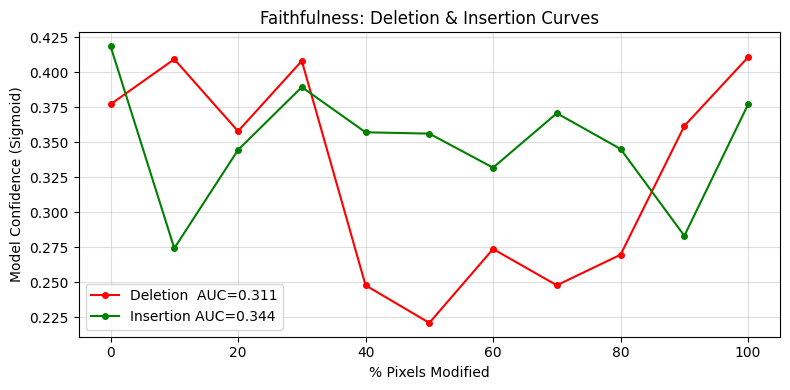

Saved → /content/drive/MyDrive/ACLInsight-Net/figures/faithfulness_curves.png
Saved → /content/drive/MyDrive/ACLInsight-Net/results/xai_metrics.csv


In [ ]:
import torch.nn.functional as F

# ── Helper: get Grad-CAM for a single input ────────────────────────────────
def get_cam_for_input(model, input_tensor, cam_engine):
    """Returns H×W numpy array of CAM activations."""
    return cam_engine(input_tensor, targets=[ClassifierOutputTarget(0)])[0]

# ── Deletion Score (Faithfulness) ─────────────────────────────────────────
def deletion_score(model, img_tensor, cam_map, steps=10):
    """
    Progressively mask top-k% most salient pixels.
    Returns (auc, confidence_curve).
    Lower AUC → explanation focuses on truly important pixels.
    """
    model.eval()
    flat_cam = cam_map.flatten()
    sorted_idx = np.argsort(flat_cam)[::-1]    # descending importance
    h, w = cam_map.shape
    total_px = h * w
    confs = []
    orig = img_tensor.clone().to(device).unsqueeze(0)

    for step in range(steps + 1):
        n_masked = int((step / steps) * total_px)
        masked = orig.clone()
        if n_masked > 0:
            ri = sorted_idx[:n_masked] // w
            ci = sorted_idx[:n_masked]  % w
            masked[0, :, ri, ci] = 0.0
        with torch.no_grad():
            confs.append(torch.sigmoid(model(masked)).item())

    x = np.linspace(0, 1, steps + 1)
    return float(np.trapz(confs, x)), confs

# ── Insertion Score ────────────────────────────────────────────────────────
def insertion_score(model, img_tensor, cam_map, steps=10):
    """
    Progressively reveal pixels on blurred baseline.
    Returns (auc, confidence_curve).
    Higher AUC → model relies on the salient region.
    """
    model.eval()
    flat_cam = cam_map.flatten()
    sorted_idx = np.argsort(flat_cam)[::-1]
    h, w = cam_map.shape
    total_px = h * w
    confs = []
    orig = img_tensor.clone().to(device).unsqueeze(0)
    baseline = F.avg_pool2d(orig, kernel_size=15, stride=1, padding=7)

    for step in range(steps + 1):
        n_reveal = int((step / steps) * total_px)
        revealed = baseline.clone()
        if n_reveal > 0:
            ri = sorted_idx[:n_reveal] // w
            ci = sorted_idx[:n_reveal]  % w
            revealed[0, :, ri, ci] = orig[0, :, ri, ci]
        with torch.no_grad():
            confs.append(torch.sigmoid(model(revealed)).item())

    x = np.linspace(0, 1, steps + 1)
    return float(np.trapz(confs, x)), confs

# ── Proxy Localization ─────────────────────────────────────────────────────
def cam_localization_stats(cam_map, threshold=0.5):
    high = cam_map >= threshold
    focus_pct = float(high.mean() * 100)
    centroid = np.argwhere(high).mean(axis=0) if high.any() else np.array([np.nan, np.nan])
    return {'max_activation': float(cam_map.max()),
            'focus_area_pct': focus_pct,
            'centroid_row': centroid[0],
            'centroid_col': centroid[1]}

# ── Run on first N_XAI positive val samples ───────────────────────────────
N_XAI = 5
target_layers = [model.backbone.blocks[-1]]
cam_engine_xai = GradCAM(model=model, target_layers=target_layers)

del_scores, ins_scores, loc_stats = [], [], []
last_del_curve = last_ins_curve = None

count = 0
for img_t, lbl, case in val_dataset:
    if int(lbl) != 1:
        continue
    inp = img_t.unsqueeze(0).to(device)
    cam_map = get_cam_for_input(model, inp, cam_engine_xai)

    d_auc, d_curve = deletion_score(model, img_t, cam_map)
    i_auc, i_curve = insertion_score(model, img_t, cam_map)
    loc = cam_localization_stats(cam_map)

    del_scores.append(d_auc)
    ins_scores.append(i_auc)
    loc_stats.append(loc)
    last_del_curve, last_ins_curve = d_curve, i_curve

    count += 1
    if count >= N_XAI:
        break

print(f"\n── XAI Quantitative Metrics (N={N_XAI} ACL+ val samples) ──────────────")
print(f"  Deletion  Score (AUC) : {np.mean(del_scores):.4f} ± {np.std(del_scores):.4f}  ↓ lower = more faithful")
print(f"  Insertion Score (AUC) : {np.mean(ins_scores):.4f} ± {np.std(ins_scores):.4f}  ↑ higher = more faithful")
print(f"  Avg Focus Area (>0.5) : {np.mean([l['focus_area_pct'] for l in loc_stats]):.1f}% of image")
print(f"  Avg Max Activation    : {np.mean([l['max_activation'] for l in loc_stats]):.4f}")

# ── Plot ───────────────────────────────────────────────────────────────────
steps = len(last_del_curve) - 1
x_pct = np.linspace(0, 100, steps + 1)
plt.figure(figsize=(8, 4))
plt.plot(x_pct, last_del_curve, 'r-o', markersize=4, label=f'Deletion  AUC={np.mean(del_scores):.3f}')
plt.plot(x_pct, last_ins_curve, 'g-o', markersize=4, label=f'Insertion AUC={np.mean(ins_scores):.3f}')
plt.xlabel('% Pixels Modified')
plt.ylabel('Model Confidence (Sigmoid)')
plt.title('Faithfulness: Deletion & Insertion Curves')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/faithfulness_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR}/faithfulness_curves.png')

# ── Save XAI metrics CSV ──────────────────────────────────────────────────
xai_data = {
    'deletion_score_mean':  float(np.mean(del_scores)),
    'deletion_score_std':   float(np.std(del_scores)),
    'insertion_score_mean': float(np.mean(ins_scores)),
    'insertion_score_std':  float(np.std(ins_scores)),
    'avg_focus_area_pct':   float(np.mean([l['focus_area_pct'] for l in loc_stats])),
    'avg_max_activation':   float(np.mean([l['max_activation'] for l in loc_stats])),
    'n_samples': len(del_scores)
}
pd.DataFrame([xai_data]).to_csv(f'{RESULTS_DIR}/xai_metrics.csv', index=False)
print(f'Saved → {RESULTS_DIR}/xai_metrics.csv')


## 18. Robustness & Generalization (k-Fold Cross-Validation)

5-fold stratified CV on the training split to report metric stability (mean ± std).  
Uses head-only training (frozen backbone) for efficiency — adjust `KFOLD_EPOCHS` for a full run.

Running 5-fold CV | 3 epochs/fold | head-only...
[train] 106,797 slices | 1130 exams | 3390 volumes cached
[train] 106,797 slices | 1130 exams | 3390 volumes cached


  Fold 1/5 — AUC: 0.7338 | F1: 0.3431 | Acc: 0.3053 | MCC: 0.1770
[train] 106,797 slices | 1130 exams | 3390 volumes cached
[train] 106,797 slices | 1130 exams | 3390 volumes cached


  Fold 2/5 — AUC: 0.7341 | F1: 0.3347 | Acc: 0.2965 | MCC: 0.1422
[train] 106,797 slices | 1130 exams | 3390 volumes cached
[train] 106,797 slices | 1130 exams | 3390 volumes cached


  Fold 3/5 — AUC: 0.7337 | F1: 0.3364 | Acc: 0.3540 | MCC: 0.1090
[train] 106,797 slices | 1130 exams | 3390 volumes cached
[train] 106,797 slices | 1130 exams | 3390 volumes cached


  Fold 4/5 — AUC: 0.7862 | F1: 0.3433 | Acc: 0.3230 | MCC: 0.1416
[train] 106,797 slices | 1130 exams | 3390 volumes cached
[train] 106,797 slices | 1130 exams | 3390 volumes cached


  Fold 5/5 — AUC: 0.7785 | F1: 0.3493 | Acc: 0.3407 | MCC: 0.1580

── 5-Fold CV Summary ─────────────────────────────────────────────────
  Metric                    Mean      Std
  --------------------------------------
  AUC-ROC                0.7533  ±0.0267
  Accuracy               0.3239  ±0.0239
  F1-Score               0.3414  ±0.0059
  Recall                 0.9523  ±0.0445
  Specificity            0.1823  ±0.0363
  Precision              0.2081  ±0.0043
  Balanced Accuracy      0.5673  ±0.0087
  MCC                    0.1456  ±0.0250
  Log Loss               0.7972  ±0.0233
  Brier Score            0.2994  ±0.0106


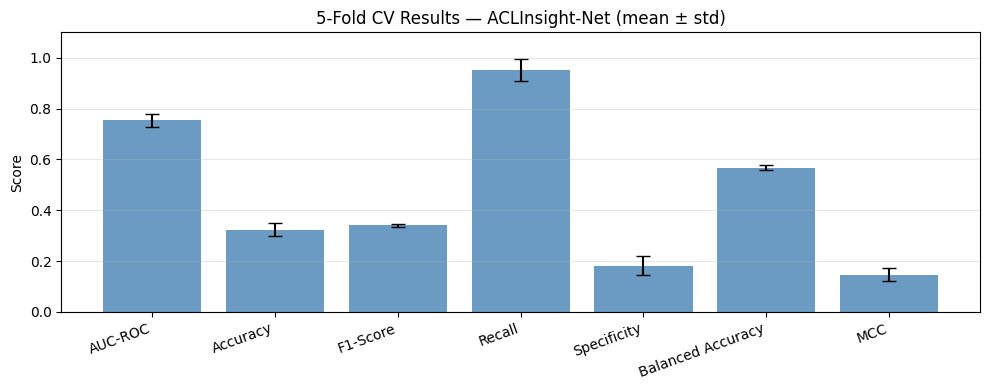

Saved → /content/drive/MyDrive/ACLInsight-Net/figures/kfold_cv_results.png
Saved → /content/drive/MyDrive/ACLInsight-Net/results/kfold_per_fold.csv
Saved → /content/drive/MyDrive/ACLInsight-Net/results/kfold_summary.csv


In [ ]:
K_FOLDS = 5
KFOLD_EPOCHS = 3       # Quick run. Increase to EPOCHS_S1 for the paper.

# Load all training case/label pairs
all_train_csv = pd.read_csv(
    TRAIN_ACL_CSV,
    header=None, names=['case', 'label']
)
cases_arr  = all_train_csv['case'].values
labels_arr = all_train_csv['label'].values

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
fold_metrics_list = []

print(f"Running {K_FOLDS}-fold CV | {KFOLD_EPOCHS} epochs/fold | head-only...")

for fold, (tr_idx, va_idx) in enumerate(skf.split(cases_arr, labels_arr), 1):
    tr_cases = set(cases_arr[tr_idx].tolist())
    va_cases = set(cases_arr[va_idx].tolist())

    # Build per-fold datasets by filtering on case IDs
    tr_ds = MRNetSliceDataset(
        root_dir=TRAIN_DIR,
        csv_path=TRAIN_ACL_CSV,
        transform=train_transform
    )
    va_ds = MRNetSliceDataset(
        root_dir=TRAIN_DIR,
        csv_path=TRAIN_ACL_CSV,
        transform=val_transform
    )
    # FIX: Unpack 4 values (npy_path, slice_idx, label, case) instead of 3
    tr_ds.samples = [(p, s, l, c) for p, s, l, c in tr_ds.samples if c in tr_cases]
    va_ds.samples = [(p, s, l, c) for p, s, l, c in va_ds.samples if c in va_cases]

    tr_ldr = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=NUM_WORKERS, pin_memory=True)
    va_ldr = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

    fold_model = ACLModel().to(device)
    freeze_backbone(fold_model, freeze=True)
    opt = optim.AdamW(
        filter(lambda p: p.requires_grad, fold_model.parameters()),
        lr=LR_S1, weight_decay=1e-4
    )
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=KFOLD_EPOCHS, eta_min=LR_S1/10)

    for ep in range(KFOLD_EPOCHS):
        train_one_epoch(fold_model, tr_ldr, opt)
        sch.step()

    yt, yp, ci = validate(fold_model, va_ldr)
    m, _ = exam_level_metrics(yt, yp, ci)
    fold_metrics_list.append(m)
    print(f"  Fold {fold}/{K_FOLDS} — AUC: {m['AUC-ROC']:.4f} | F1: {m['F1-Score']:.4f} | Acc: {m['Accuracy']:.4f} | MCC: {m['MCC']:.4f}")

# ── Summary Table ─────────────────────────────────────────────────────────
kf_df = pd.DataFrame(fold_metrics_list)
report_cols = ['AUC-ROC', 'Accuracy', 'F1-Score', 'Recall',
               'Specificity', 'Precision', 'Balanced Accuracy', 'MCC',
               'Log Loss', 'Brier Score']

print("\n── 5-Fold CV Summary ─────────────────────────────────────────────────")
print(f"  {'Metric':<22} {'Mean':>7}  {'Std':>7}")
print("  " + "-"*38)
for col in report_cols:
    if col in kf_df.columns:
        print(f"  {col:<22} {kf_df[col].mean():.4f}  ±{kf_df[col].std():.4f}")

# ── Plot k-Fold CV bars ───────────────────────────────────────────────────
plot_cols = ['AUC-ROC', 'Accuracy', 'F1-Score', 'Recall', 'Specificity',
             'Balanced Accuracy', 'MCC']
means = [kf_df[c].mean() for c in plot_cols if c in kf_df]
stds  = [kf_df[c].std()  for c in plot_cols if c in kf_df]
labels = [c for c in plot_cols if c in kf_df]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(labels, means, yerr=stds, capsize=5, color='steelblue', alpha=0.8)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title(f'{K_FOLDS}-Fold CV Results — ACLInsight-Net (mean ± std)')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/kfold_cv_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR}/kfold_cv_results.png')

# ── Save per-fold + summary CSV ───────────────────────────────────────────
kf_df.to_csv(f'{RESULTS_DIR}/kfold_per_fold.csv', index_label='fold')
summary = kf_df.agg(['mean', 'std']).T
summary.columns = ['mean', 'std']
summary.to_csv(f'{RESULTS_DIR}/kfold_summary.csv')
print(f'Saved → {RESULTS_DIR}/kfold_per_fold.csv')
print(f'Saved → {RESULTS_DIR}/kfold_summary.csv')

## 19. Ablation Study

Systematic comparison of three model configurations to justify design decisions.

| Variant | Description |
|---|---|
| **Stage-1 Only** | EfficientNet-B0, frozen backbone, head trained only |
| **Stage-2 FT** | + Last 2 blocks fine-tuned |
| **Full ACLInsight-Net** | Best checkpoint, evaluated at exam-level |

> **For SSL ablation in the paper:** Pre-train with SimCLR on unlabelled MRI slices  
> (separate notebook), load weights, then compare AUC vs. ImageNet-only init.


── Ablation Study ────────────────────────────────────────────────────
                                              AUC-ROC  Accuracy  F1-Score  Recall  Specificity
Variant                                                                                       
Stage-1 Only\n(Frozen backbone)                0.8544    0.6917    0.7259  0.9074       0.5152
Stage-2 Fine-Tune\n(Last 2 blocks)             0.9641    0.5583    0.6708  1.0000       0.1970
Full ACLInsight-Net\n(Weighted Ensemble TTA)   0.9512    0.9083    0.9009  0.9259       0.8939


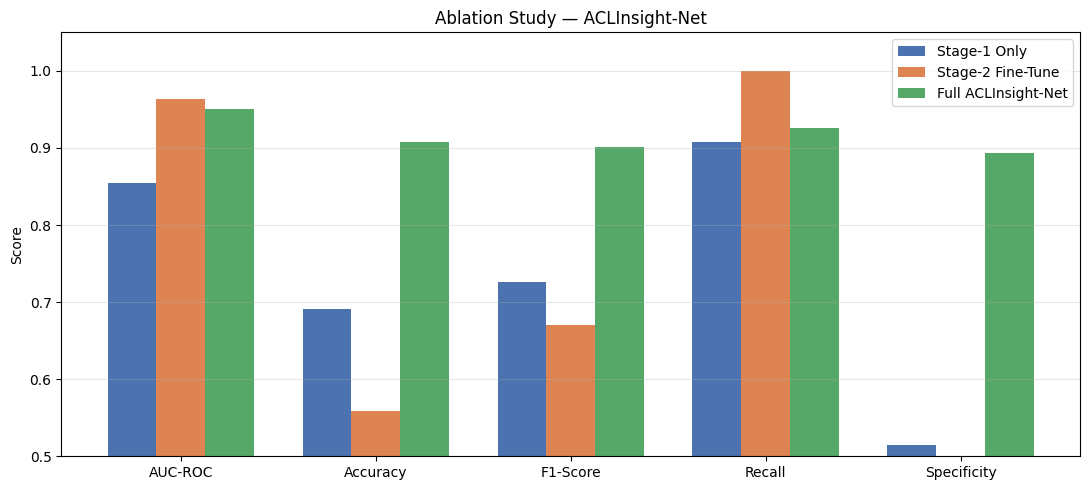

Saved → /content/drive/MyDrive/ACLInsight-Net/figures/ablation_study.png
Saved → /content/drive/MyDrive/ACLInsight-Net/results/ablation_study.csv


In [ ]:
# ── Ablation Configurations ───────────────────────────────────────────────
ablation_results = []

# Config A: Stage-1 best epoch (head-only, Sagittal example)
if 'hist_s1' in dir():
    s1_best = hist_s1.loc[hist_s1['AUC-ROC'].idxmax()]
    ablation_results.append({
        'Variant': 'Stage-1 Only\n(Frozen backbone)',
        'Accuracy':    s1_best.get('Accuracy', float('nan')),
        'AUC-ROC':     s1_best.get('AUC-ROC',  float('nan')),
        'F1-Score':    s1_best.get('F1-Score',  float('nan')),
        'Recall':      s1_best.get('Recall',    float('nan')),
        'Specificity': s1_best.get('Specificity', float('nan')),
    })

# Config B: Stage-2 best epoch (fine-tuned, Sagittal example)
if 'hist_s2' in dir():
    s2_best = hist_s2.loc[hist_s2['AUC-ROC'].idxmax()]
    ablation_results.append({
        'Variant': 'Stage-2 Fine-Tune\n(Last 2 blocks)',
        'Accuracy':    s2_best.get('Accuracy', float('nan')),
        'AUC-ROC':     s2_best.get('AUC-ROC',  float('nan')),
        'F1-Score':    s2_best.get('F1-Score',  float('nan')),
        'Recall':      s2_best.get('Recall',    float('nan')),
        'Specificity': s2_best.get('Specificity', float('nan')),
    })

# Config C: Full model (Weighted Ensemble)
ablation_results.append({
    'Variant': 'Full ACLInsight-Net\n(Weighted Ensemble TTA)',
    'Accuracy':    metrics['Accuracy'],
    'AUC-ROC':     metrics['AUC-ROC'],
    'F1-Score':    metrics['F1-Score'],
    'Recall':      metrics['Recall'],
    'Specificity': metrics['Specificity'],
})

abl_df = pd.DataFrame(ablation_results).set_index('Variant')
print("\n── Ablation Study ────────────────────────────────────────────────────")
cols = ['AUC-ROC', 'Accuracy', 'F1-Score', 'Recall', 'Specificity']
print(abl_df[cols].to_string(float_format='{:.4f}'.format))

# ── Bar Chart ─────────────────────────────────────────────────────────────
metrics_to_plot = cols
x = np.arange(len(metrics_to_plot))
width = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']
short_labels = [r.split('\n')[0] for r in abl_df.index]

fig, ax = plt.subplots(figsize=(11, 5))
for i, (row, color, lbl) in enumerate(zip(ablation_results, colors, short_labels)):
    vals = [row[m] for m in metrics_to_plot]
    ax.bar(x + i * width, vals, width, label=lbl, color=color)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Score')
ax.set_title('Ablation Study — ACLInsight-Net')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR}/ablation_study.png')

# ── Save ablation CSV ─────────────────────────────────────────────────────
abl_df.reset_index().to_csv(f'{RESULTS_DIR}/ablation_study.csv', index=False)
print(f'Saved → {RESULTS_DIR}/ablation_study.csv')
